### 1.1.7.29. Stochastic Matrix


$$
P_{ij} \geq 0
\qquad
\sum_{j=1}^{n} P_{ij} = 1 \quad \text{for all } i
$$


**Explanation:**

A (row-)stochastic matrix has nonnegative entries where each row sums to 1, encoding the transition probabilities of a discrete-time Markov chain: $P_{ij}$ is the probability of moving from state $i$ to state $j$ in one step. Every stochastic matrix has $\lambda = 1$ as an eigenvalue, and the corresponding stationary distribution $\boldsymbol{\pi}$ satisfies $\boldsymbol{\pi}^{\mathsf{T}} P = \boldsymbol{\pi}^{\mathsf{T}}$ with $\sum_i \pi_i = 1$. For a regular stochastic matrix—one for which some power $P^k$ has all strictly positive entries—repeated application of $P$ drives any initial state distribution to $\boldsymbol{\pi}$.

**Properties:**

- All entries $P_{ij} \geq 0$ and all row sums equal 1.
- The [spectral radius](./30_spectral_radius.ipynb) equals 1; $\lambda = 1$ is always an eigenvalue.
- All other eigenvalues satisfy $|\lambda_i| \leq 1$.
- For a regular stochastic matrix, the stationary distribution $\boldsymbol{\pi}$ is unique.
- The all-ones vector $\mathbf{1}$ is always a right eigenvector for $\lambda = 1$.

**Example:**

For the first row of

$$
P=\begin{bmatrix}7/10&1/5&1/10\\3/10&1/2&1/5\\1/10&3/10&3/5\end{bmatrix},
$$

the row sum is

$$
\frac{7}{10}+\frac{1}{5}+\frac{1}{10}
=\frac{7}{10}+\frac{2}{10}+\frac{1}{10}=1.
$$

The other rows also sum to $1$:

$$
\frac{3}{10}+\frac{1}{2}+\frac{1}{5}=\frac{3}{10}+\frac{5}{10}+\frac{2}{10}=1,
$$

and

$$
\frac{1}{10}+\frac{3}{10}+\frac{3}{5}=\frac{1}{10}+\frac{3}{10}+\frac{6}{10}=1.
$$

Solving $P^T\boldsymbol{\pi}=\boldsymbol{\pi}$ with $\sum_i\pi_i=1$ gives

$$
\boldsymbol{\pi}=\begin{bmatrix}7/17&11/34&9/34\end{bmatrix}.
$$


In [1]:
import sympy as sp

transition = sp.Matrix([
    [sp.Rational(7, 10), sp.Rational(1, 5), sp.Rational(1, 10)],
    [sp.Rational(3, 10), sp.Rational(1, 2), sp.Rational(1, 5)],
    [sp.Rational(1, 10), sp.Rational(3, 10), sp.Rational(3, 5)],
])
row_sums = [sum(transition.row(index)) for index in range(transition.rows)]
eigenvalues = sorted(transition.eigenvals(), key=float, reverse=True)
stationary_kernel = (transition.T - sp.eye(3)).nullspace()[0]
stationary_distribution = stationary_kernel / sum(stationary_kernel)

print("row sums                =", row_sums)
print("eigenvalues             =", eigenvalues)
print("stationary distribution =")
sp.pprint(stationary_distribution.T)

row sums                = [1, 1, 1]
eigenvalues             = [1, sqrt(2)/10 + 2/5, 2/5 - sqrt(2)/10]
stationary distribution =
⎡      11      ⎤
⎢7/17  ──  9/34⎥
⎣      34      ⎦


transition_exact =
⎡7/10  1/5   1/10⎤
⎢                ⎥
⎢3/10  1/2   1/5 ⎥
⎢                ⎥
⎣1/10  3/10  3/5 ⎦
row_sums = [1, 1, 1]
initial_state = [1. 0. 0.]
state_after_30_steps = [0.41176471 0.32352941 0.26470588]


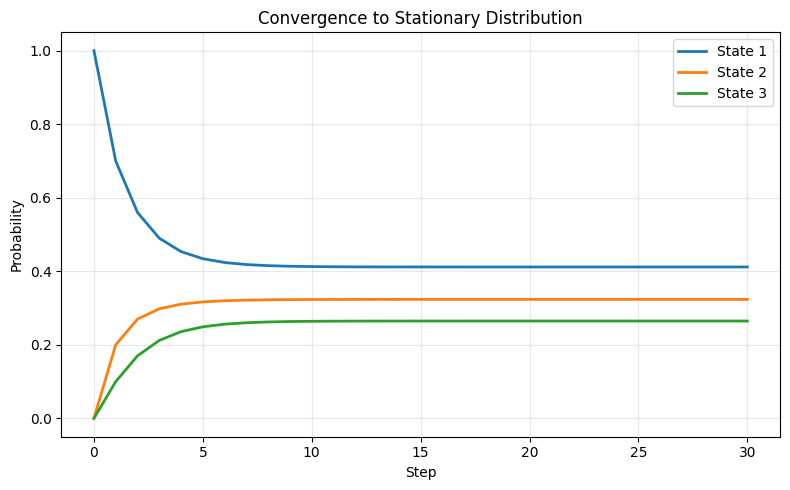

In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

transition_exact = sp.Matrix([
    [sp.Rational(7, 10), sp.Rational(1, 5), sp.Rational(1, 10)],
    [sp.Rational(3, 10), sp.Rational(1, 2), sp.Rational(1, 5)],
    [sp.Rational(1, 10), sp.Rational(3, 10), sp.Rational(3, 5)],
])
row_sums = [sum(transition_exact.row(index)) for index in range(transition_exact.rows)]
transition = np.array(transition_exact.tolist(), dtype=float)

steps = 30
state_trajectory = np.zeros((steps + 1, 3))
state_trajectory[0] = [1.0, 0.0, 0.0]

for step in range(steps):
    state_trajectory[step + 1] = transition.T @ state_trajectory[step]

stationary_estimate = state_trajectory[-1]

print("transition_exact =")
sp.pprint(transition_exact)
print("row_sums =", row_sums)
print("initial_state =", state_trajectory[0])
print("state_after_30_steps =", stationary_estimate)

plt.figure(figsize=(8, 5))
plt.plot(state_trajectory[:, 0], label="State 1", linewidth=2)
plt.plot(state_trajectory[:, 1], label="State 2", linewidth=2)
plt.plot(state_trajectory[:, 2], label="State 3", linewidth=2)
plt.xlabel("Step")
plt.ylabel("Probability")
plt.title("Convergence to Stationary Distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**References:**

[📗 Strang, G. (2016). *Introduction to Linear Algebra*, 5th ed., Section 10.3 "Markov Matrices".](https://math.mit.edu/~gs/linearalgebra/)

---

[⬅️ Previous: Singular Value Decomposition](./28_singular_value_decomposition.ipynb) | [Next: Spectral Radius ➡️](./30_spectral_radius.ipynb)

---
